In [1]:
import xgi
import numpy as np
import pickle
from tqdm import tqdm
from had_model import *
import matplotlib.pyplot as plt

# Final vs initial node hyperdegree

In [3]:
### SET PARAMETERS OF THE MODEL
Ns = [1000, 5000]
cond = 'max_min'    # 'max_min' or 'std'
ks_avg = [0,0,10]   # hyperedge structure of initial hypergraph (e.g. [3,0,3] means avg degree at sizes s=2,4 is k_s=3)
epsilons = [0.1, 0.4]

k0_k_eps = dict()

for eps in epsilons:

    k0_k_N = dict()
    
    for N in tqdm(Ns):

        H_0 = stratified_er_hypergraph(N, ks_avg, p_type='degree')
        H_0.cleanup()
        groups_0 = H_0.edges.members()
        
        Model = HAD_model(eps, groups_0)
        results = Model.simulate(condition=cond)
        opinions = results['opinions']
        groups = results['groups']
        
        # groups at the end of the simulation
        hedges_fin = groups[-1]
        h = xgi.Hypergraph(hedges_fin)
        # hyperdegrees
        hds = h.nodes.degree.asdict()
        # hyperdegrees in the initial hypergraph
        hds_0 = H_0.nodes.degree.asdict()
        k0_k_N[N] = [
            [hds_0[n] for n in h.nodes],
            [hds[n] for n in h.nodes]
        ]

    k0_k_eps[eps] = k0_k_N

100%|█████████████████████████████████████████████| 2/2 [02:00<00:00, 60.13s/it]


epsilon=0.1, N=1000 - Pearson correlation: 0.524180846129909 p_value: 1.1491523406436144e-71 

epsilon=0.1, N=5000 - Pearson correlation: 0.5506890118856932 p_value: 0.0 

epsilon=0.4, N=1000 - Pearson correlation: 0.8333030233927067 p_value: 3.776582747668805e-259 

epsilon=0.4, N=5000 - Pearson correlation: 0.8249913565567834 p_value: 0.0 



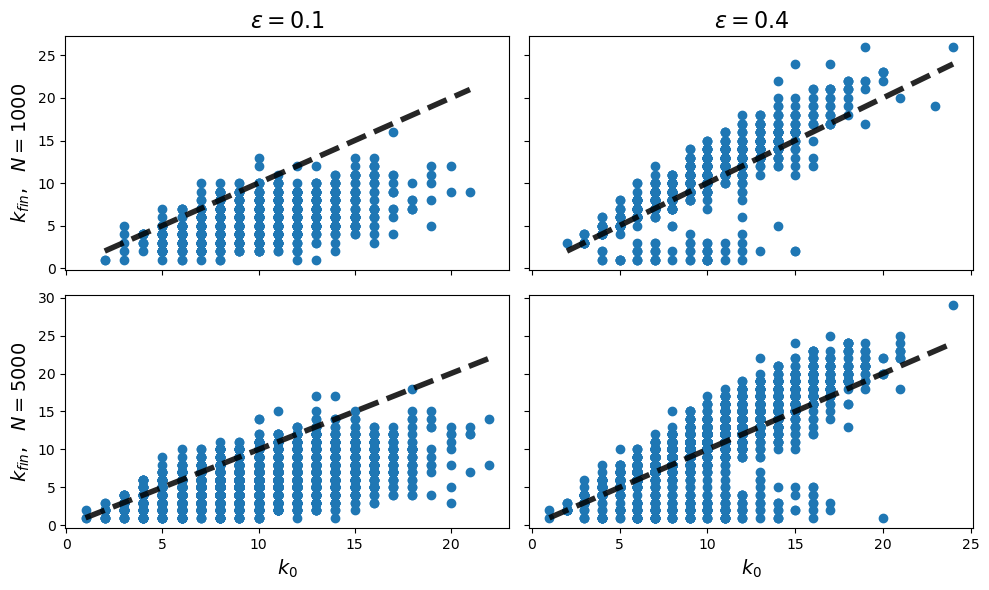

In [5]:
from scipy.stats import pearsonr

nrow, ncol = len(Ns), len(epsilons)
fig, axs = plt.subplots(nrow, ncol, sharex='col', sharey='row', figsize=(nrow*5,ncol*3))

for j,eps in enumerate(epsilons):
    for i,N in enumerate(Ns):

        k0 = k0_k_eps[eps][N][0]
        k_fin = k0_k_eps[eps][N][1]
        
        axs[i,j].plot([min(k0),max(k0)], [min(k0),max(k0)], ls='--', lw=4, color='black', alpha=0.85)
        axs[i,j].scatter(k0, k_fin, linewidths=1)
        axs[i,0].set_ylabel(r'$k_{fin},\ $'+fr'$\ N={N}$', fontsize=14)

        r, p_value = pearsonr(k0, k_fin)
        print(f'epsilon={eps}, N={N} - Pearson correlation:', r, 'p_value:', p_value, '\n')

    axs[1,j].set_xlabel(r'$k_0$', fontsize=14)
    axs[0,j].set_title(rf'$\epsilon = {eps}$', fontsize=16)

plt.tight_layout()
plt.show()

# $|e|_{max}$ as a function of $N$, for fixed $\epsilon$

In [ ]:
### SET PARAMETERS OF THE MODEL
Ns = [500, 1000, 2000, 4000, 8000, 16000]
cond = 'max_min'    # 'max_min' or 'std'
ks_avg = [0,0,10]   # hyperedge structure of initial hypergraph (e.g. [3,0,3] means avg degree at sizes s=2,4 is k_s=3)
iterations = 20     # number of runs for each epsilon
n_process = 7       # number of processes for parallelization

results = dict()

for epsilon in [0.1, 0.3, 0.4]:

    e_max = []
    
    for N in tqdm(Ns):
    
        p = Pool(processes=n_process)
        args = [(N, ks_avg, epsilon, cond, False, [0.,0.], 0.1)] * iterations
        res_runs = p.map(get_results, args)
        
        emax_it = []
        # loop over iterations
        for res in res_runs:                 
            groups_fin = res[0][-1]
            emax_it.append( max([len(e) for e in groups_fin]) )

        e_max.append(np.average(emax_it))

    results[epsilon] = {'Ns': Ns, 'e_max': e_max}

# save results
s_str, it = '', 0
while it < len(ks_avg):
    if ks_avg[it]>0.1:
        s_str += f'{it+2}'
    it +=1
    
with open(f'../results/ER_{cond}_e_max_M{s_str}.pkl', 'wb') as f:
            pickle.dump(results, f)

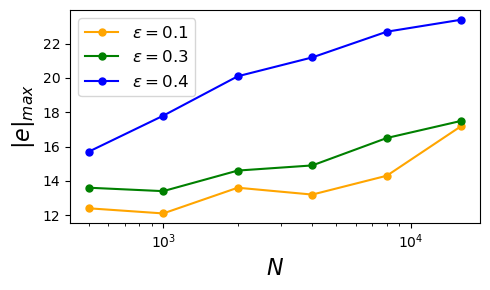

In [17]:
cond = 'max_min'
M = 4

with open(f'../results/ER_{cond}_e_max_M{M}.pkl', 'rb') as f:
    results_em = pickle.load(f)

epsilons = [0.1, 0.3, 0.4]
clrs = ['orange', 'green', 'blue']

plt.figure(figsize=(5,3))

for eps,clr in zip(epsilons, clrs):
    x2 = results_em[eps]['Ns']
    y2 = results_em[eps]['e_max']
    plt.plot(x2, y2, color=clr, marker='o', markersize=5, label=fr'$\epsilon = {eps}$')
    plt.xscale('log')
    plt.ylabel(r'$|e|_{max}$', fontsize=16)
    plt.xlabel(r'$N$', fontsize=16)
    plt.legend(fontsize=12)

plt.tight_layout()
#plt.savefig(f'../figures/ER_{cond}_e_max_M{M}.jpg', dpi=dpi)
plt.show()